### Working with asymmetrical lines

We start this tutorial by loading the same data used in the [spectral analysis](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb) tutorial for the blazar PKSJ0049-5738.

Let's start by importing the `analysis()` class from **easyspec**:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from easyspec.analysis import analysis
analysis = analysis()

easyspec-cleaning version:  1.0.0
easyspec-extraction version:  1.0.2


Let's load our data (change the data paths according to your own directories):

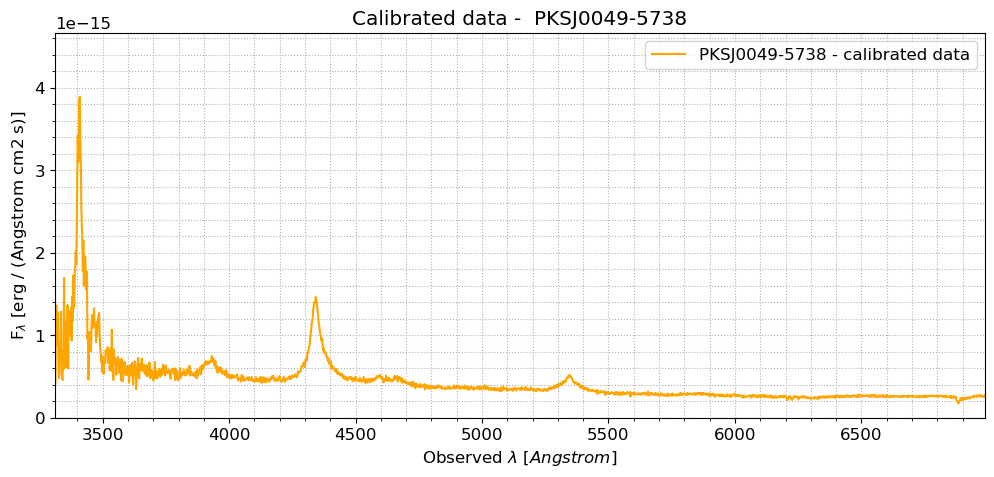

In [2]:
wavelengths, flux_density = analysis.load_calibrated_data("./PKSJ0049-5738_results/PKSJ0049-5738_spec_0.dat",
                                          target_name="PKSJ0049-5738", output_dir = "./PKSJ0049-5738_results", plot = True)

## Finding the lines

For details about the function below, please follow the [spectral analysis](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb) tutorial.

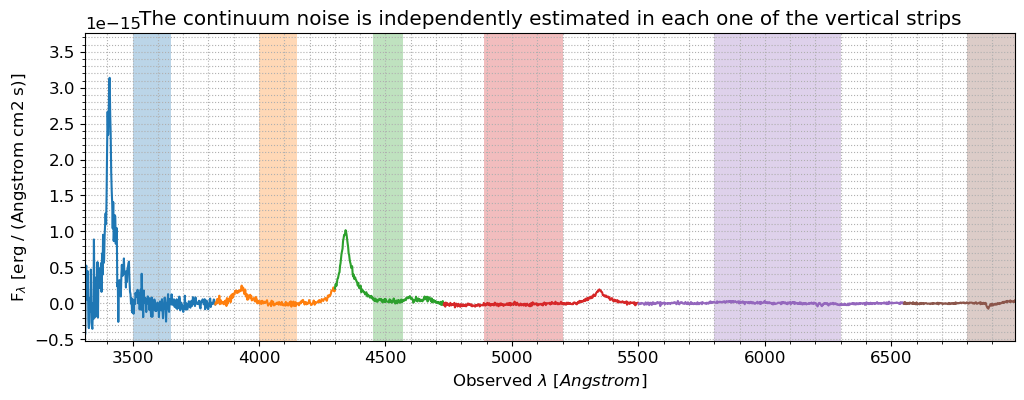

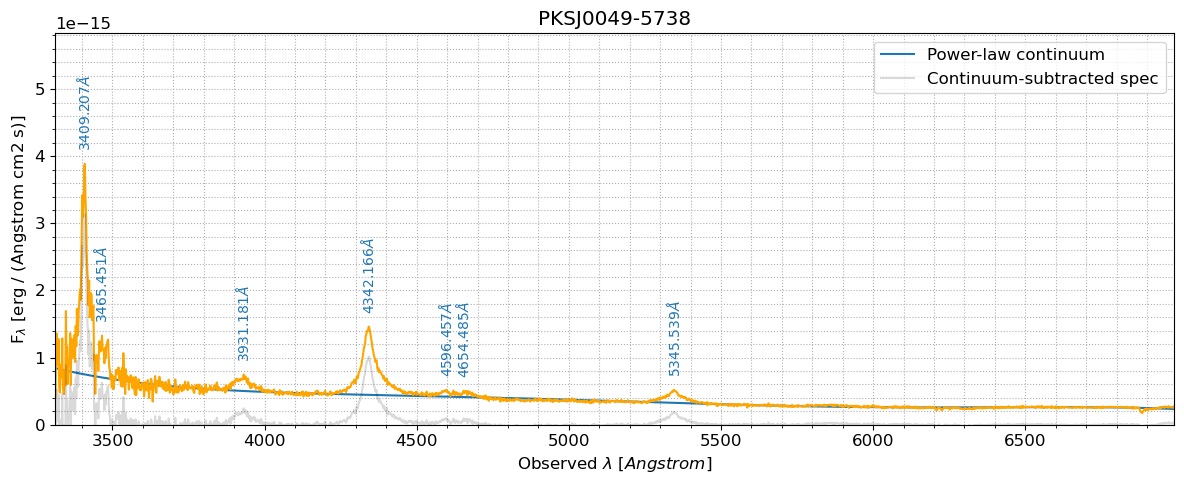

In [3]:
continuum_regions = [[3500,3650],[4000,4150],[4450,4570],[4890,5200],[5800,6300],[6800,7000]]
continuum_baseline, line_std_deviation, wavelength_peak_positions, peak_heights, line_significance = analysis.find_lines(wavelengths, flux_density,
                    line_significance_sigma = 5, peak_distance = 25,
                    peak_width = 2.7, method="pl", continuum_regions=continuum_regions, pl_order=5,
                    smooth_window=55,plot_lines = True, plot_regions = True, save_plot = True)

Our analysis revealed seven significant ($>5\sigma$) emission lines in the spectrum. For the purpose of this tutorial, we will concentrate on the subset that exhibits an asymmetric profile. The primary line of interest is CIV, whose asymmetry also affects the profiles of neighboring lines, specifically HeII and OIII].

If you don't recognize these lines directly from the plot above, take a look at the [spectral analysis](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb) tutorial.

The next step is to isolate these three lines from the `wavelength_peak_positions` array. We will then compile the following properties for each line into separate lists:

*   Rest-frame wavelength
*   Line name (optional)
*   Estimated peak height
*   Standard deviation of the background in the local spectral region.

In [4]:
wavelength_peak_positions_slice = wavelength_peak_positions[[3,4,5]]
rest_frame_line_wavelengths = [1549, 1640.4, 1664] 
line_names = ["CIV","HeII","O_III]"] 
peak_heights_slice = peak_heights[[3,4,5]]
line_std_deviation_slice = line_std_deviation[[3,4,5]]

### Line Modeling Approach

The rest-frame wavelengths provided for the doublet lines are rounded values. Please refine these values as needed for your specific analysis.

Given that the CIV line profile is distorted by strong, blueshifted winds from the accretion disk, a standard symmetric profile is not sufficient. To accurately capture this asymmetry, we will model the line using a **skewed Lorentzian** (you can also try the **skewed Gaussian**) profile.

Let's now define the specific models for each emission line:

In [5]:
which_models= ["Skewed_Lorentzian","Lorentzian","Lorentzian"] # you can also use strings like "lorentzian" or "Lorentz" or other variations and it will still work.

Furthermore, you can instruct `easyspec` to display the lines of specific elements by defining the list below:

In [6]:
overplot_archival_lines = ["H","He","O","Ne","C","Si","N"]

## Running the MCMC

Before estimating the parameters, the user can set the **priors** for each individual line, as described in the [spectral analysis](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb) tutorial. At this point, we will use the automatic priors from `easyspec`:

In [7]:
priors = None

Running burn-in...
Running production...


Single-core processing took 7.7 seconds


Running burn-in...
Running production...
Single-core processing took 1.1 seconds
Archival lines are taken from NIST Atomic Spectra database: https://www.nist.gov/pml/atomic-spectra-database
We adopt vacuum wavelengths for lines with wavelengths < 2000 Angstroms and air wavelengths for lines with wavelengths > 2000 Angstroms.
If you use these lines in your research, please cite the NIST Atomic Spectra database appropriately.


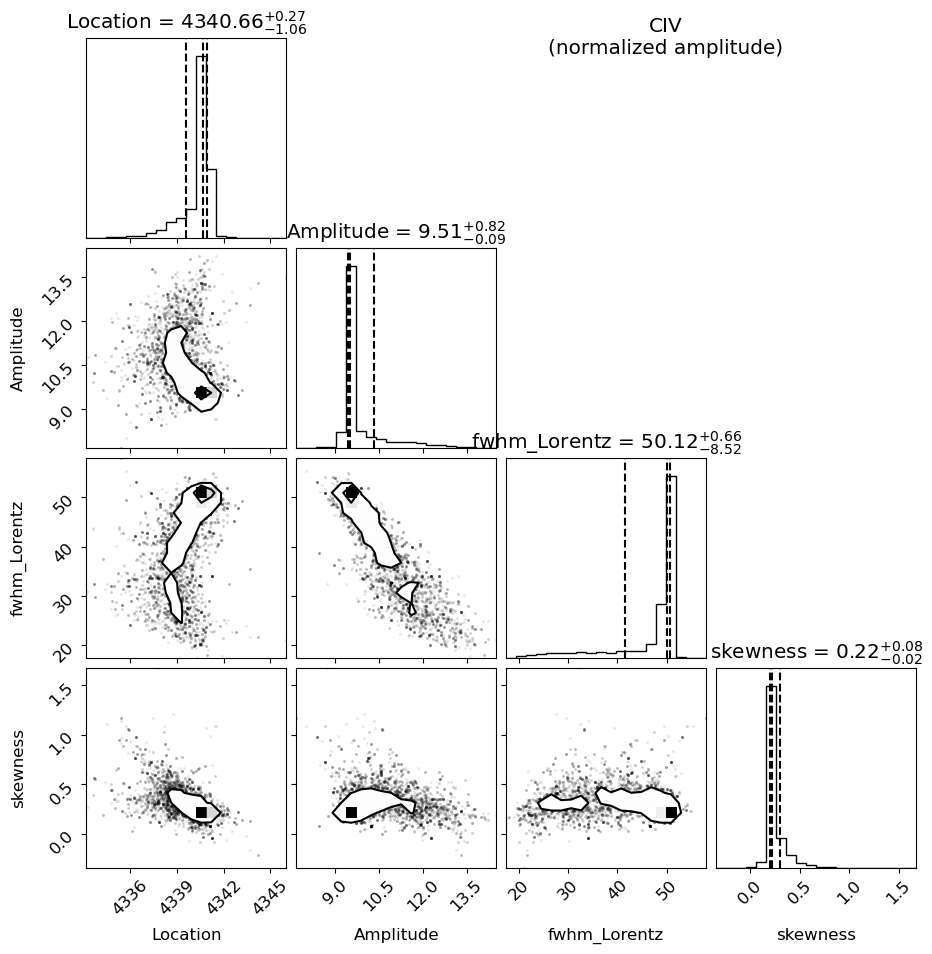

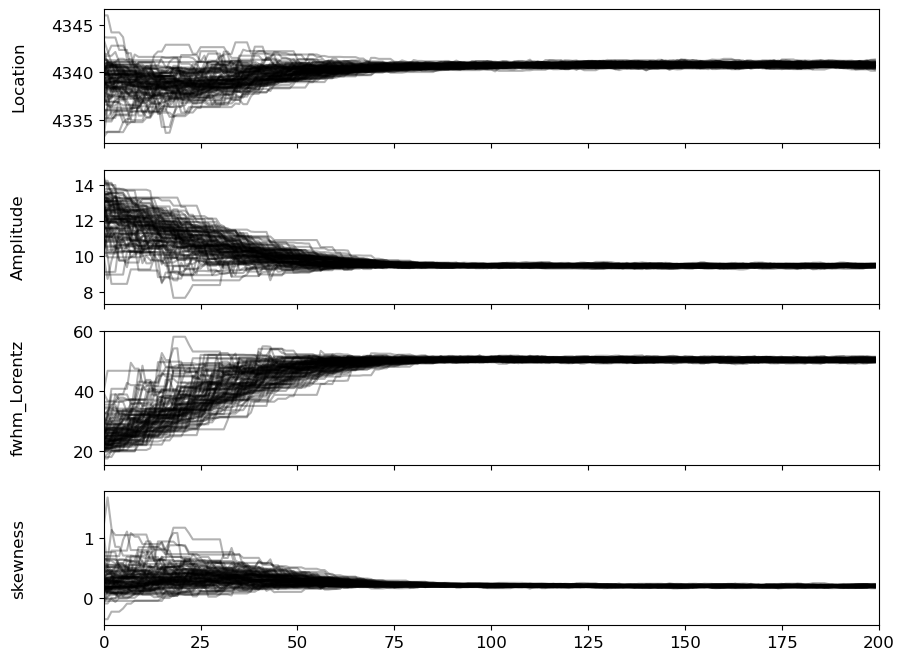

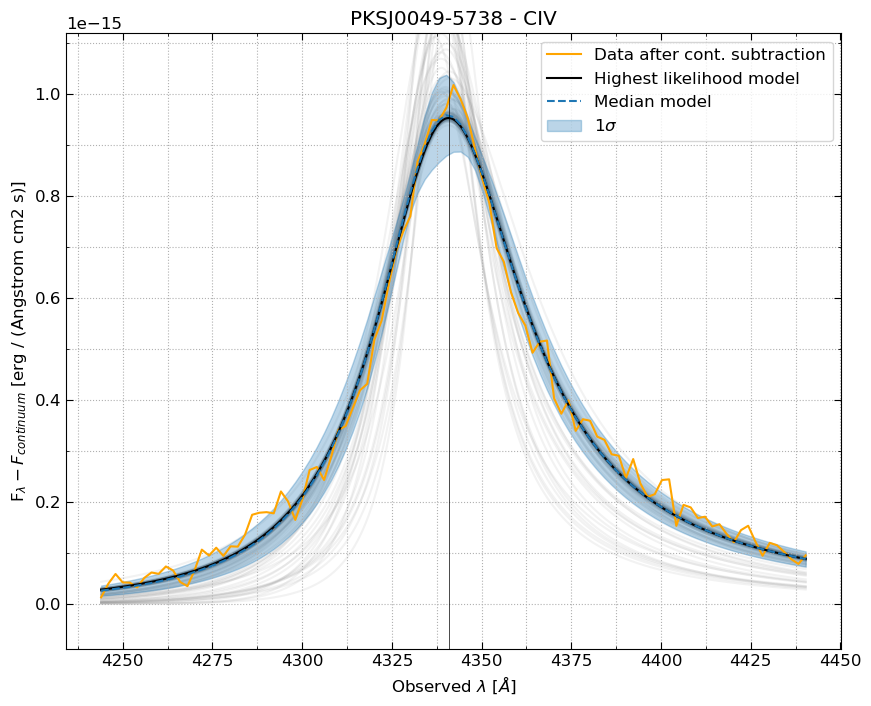

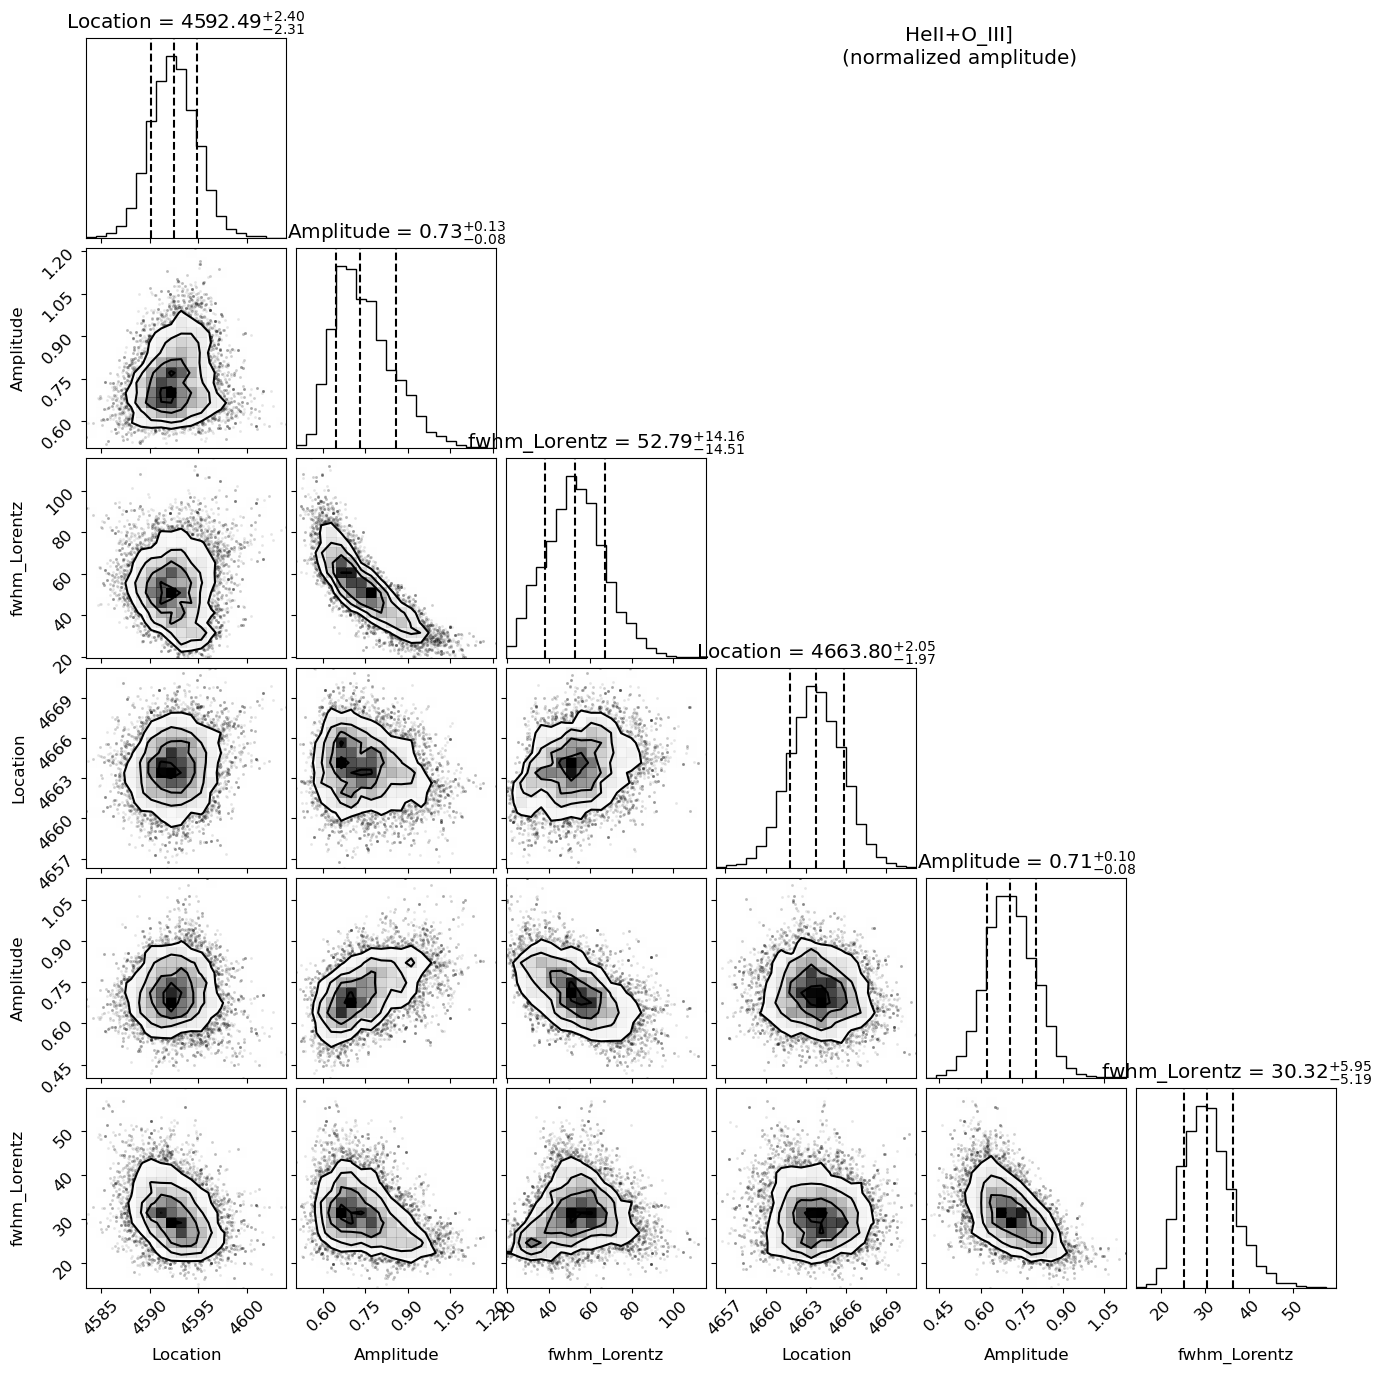

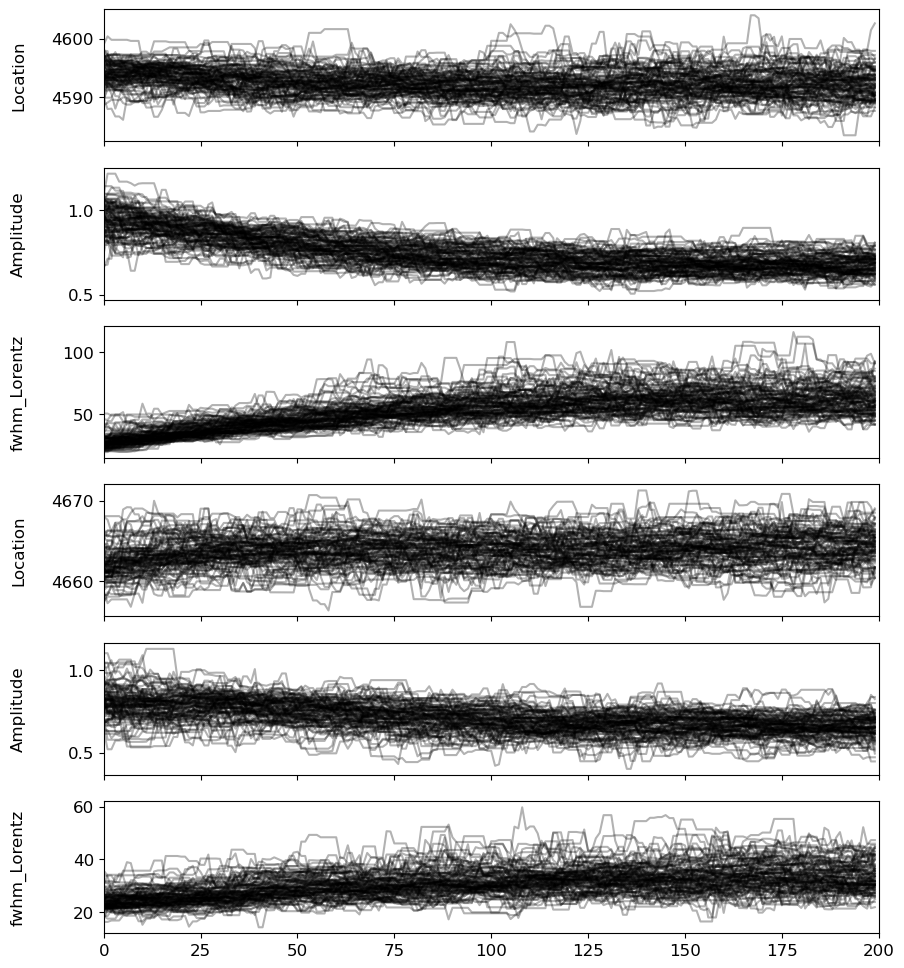

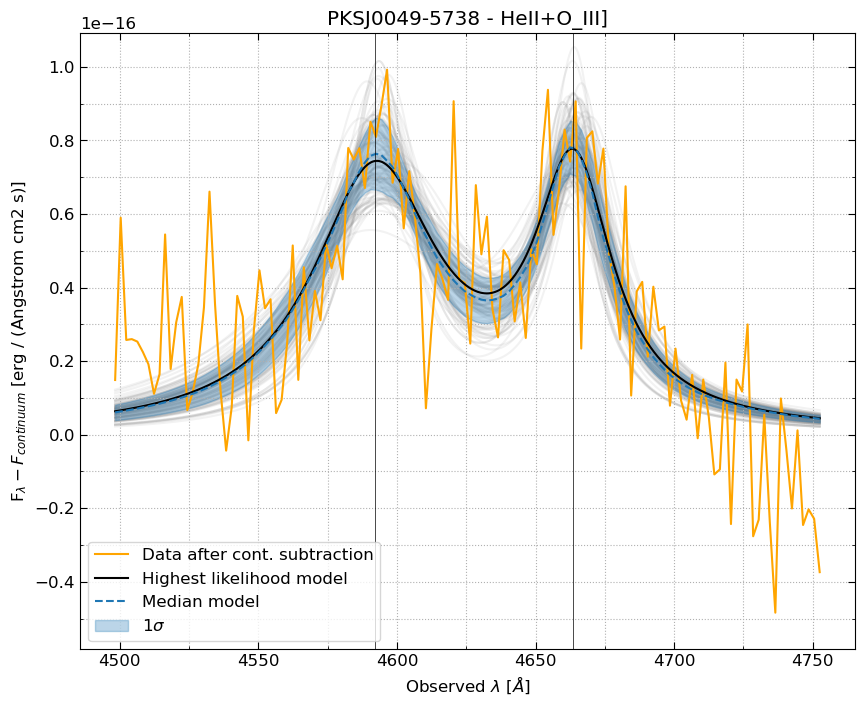

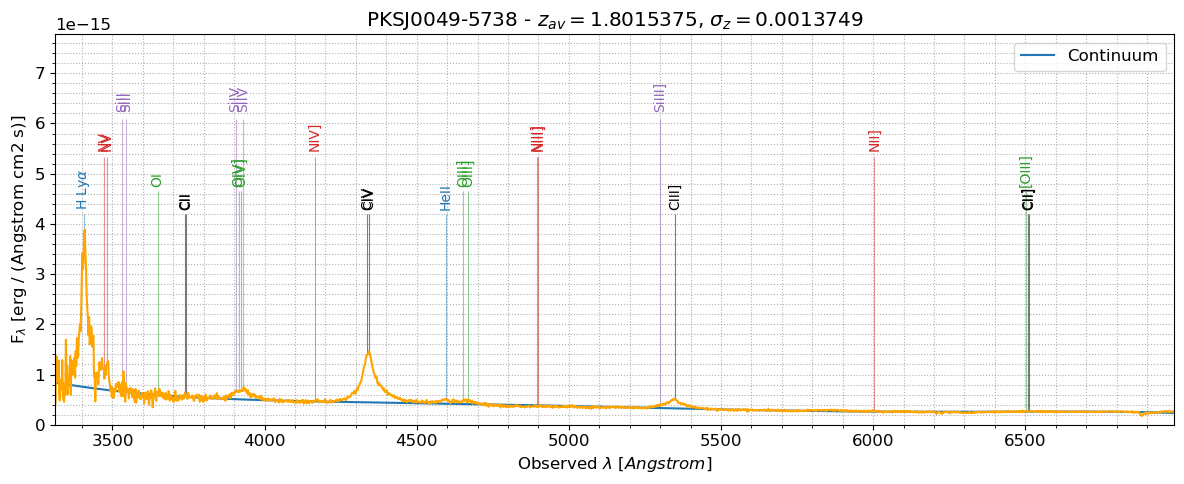

In [8]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 80, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 100, MCMC_iterations = 200, MCMC_burn_in=100, MCMC_show_progress=False, plot_spec = True, plot_MCMC = True,
                    overplot_median_model = True, save_results=True)

The initial results look promising. However, you may have noticed that the right-side wing of the skewed CIV line is contaminating the continuum near the HeII line (It is actually common to observe significant FeII and FeIII emission in this region, but let us assume that it all originates from the CIV wing).

Let's address this by fitting a blended model. Below we run the `fit_lines()` function again, but this time with the following parameters to account for the line overlap and improve the MCMC sampling:

*   `blended_line_min_separation = 350` (this is in Angstroms)
*   `MCMC_walkers = 150`
*   `MCMC_iterations = 400`

Running burn-in...
Running production...
Single-core processing took 19.4 seconds


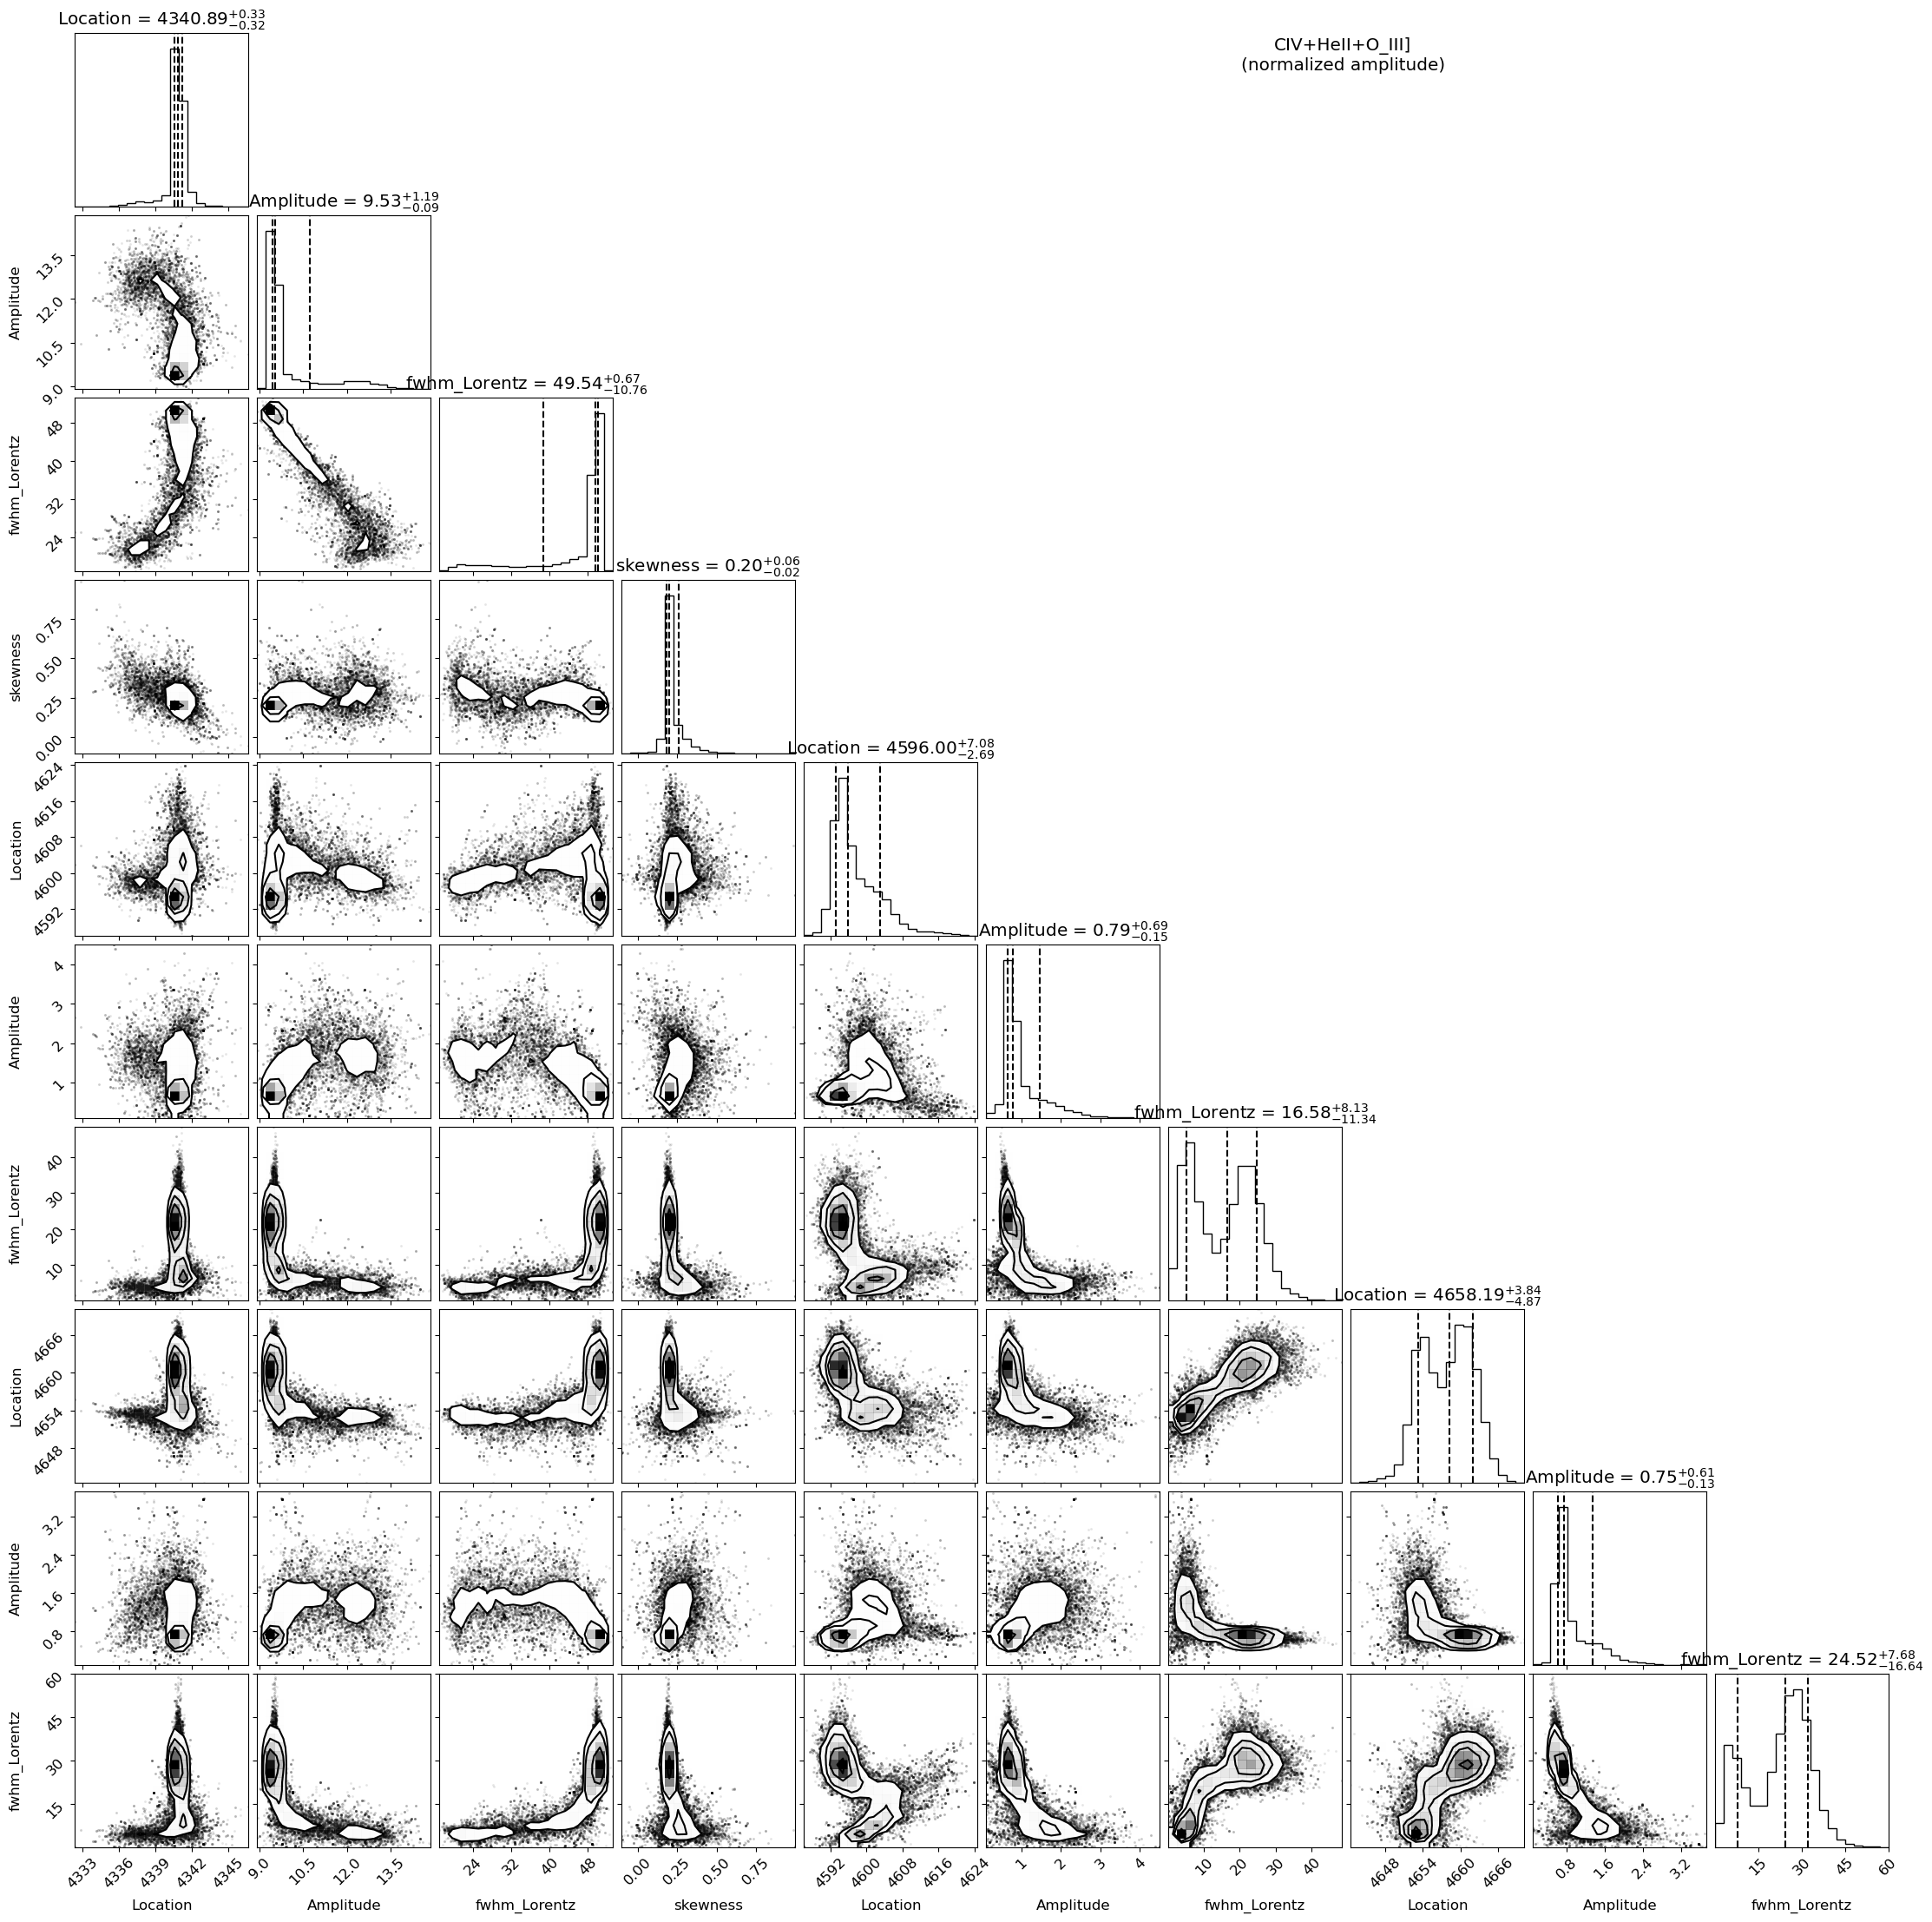

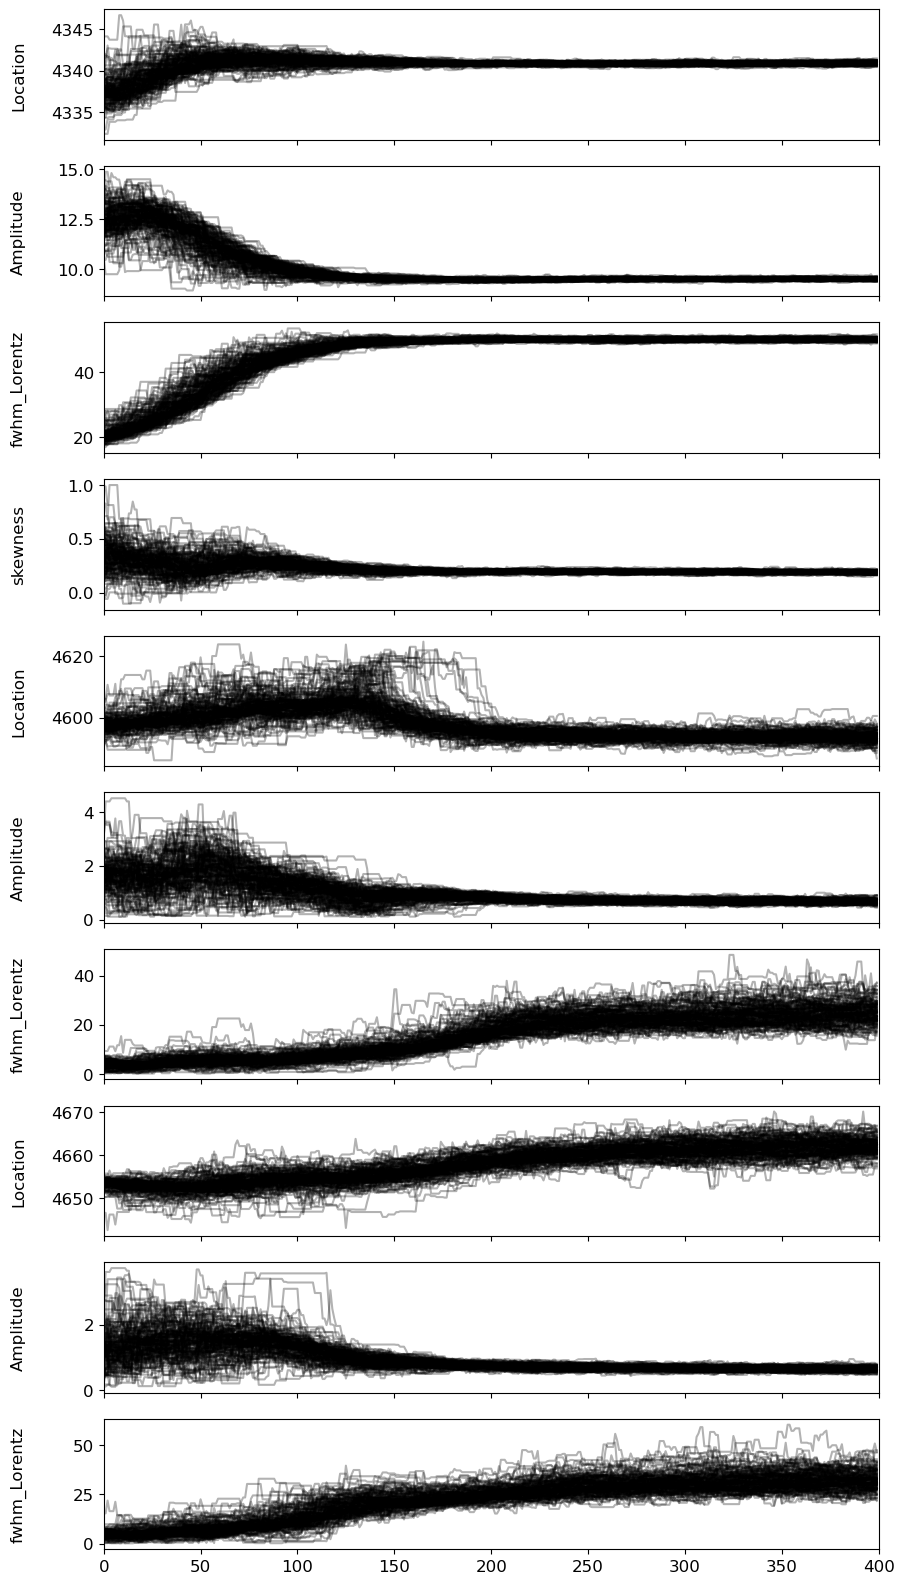

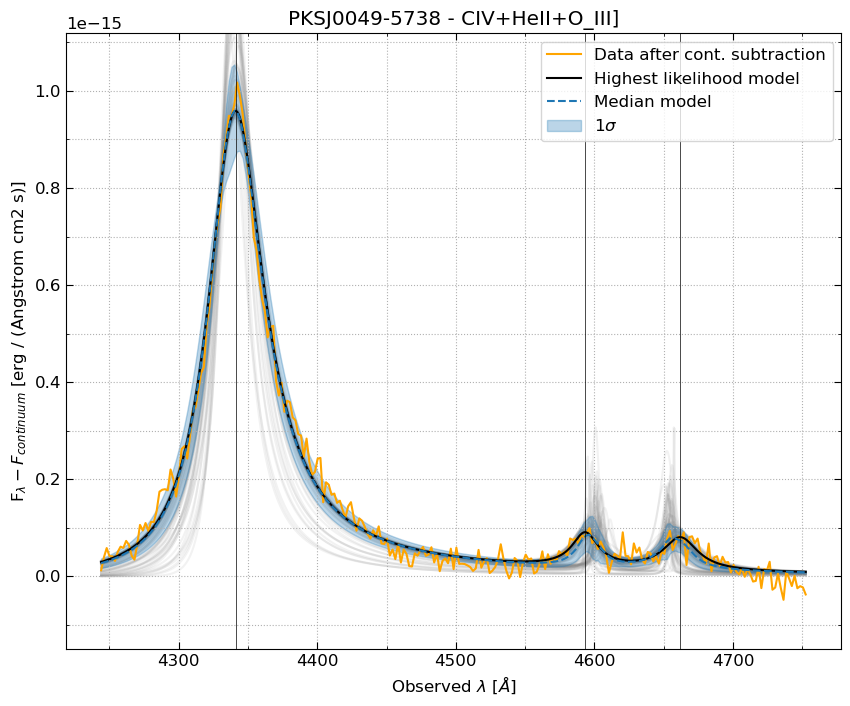

In [9]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 350, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 150, MCMC_iterations = 400, MCMC_burn_in=100, MCMC_show_progress=False, plot_spec = False, plot_MCMC = True,
                    overplot_median_model = True, save_results=True)

Very good. We are moving in the right direction, but there is still room for improvement.

> **Note on performance**
> Please be aware that the skewed models require significantly more computational power and will consequently take longer to run.

> **Note on model parameterization**
> The skewed models are parameterized in terms of the line peak. This means the **location** parameter provided in the `par_values_list` and `par_names_list` (see the cell below) refers to the **line peak wavelength** ($\lambda_{peak}$), and not to the mean of the underlying symmetric Lorentzian or Gaussian components.
>
> For a detailed explanation of the model mathematics, please refer to the [official documentation](https://easyspec.readthedocs.io/en/latest/line_models.html).

In [10]:
# par_names_list and par_values_list are the outputs from fit_lines()
# The values below correspond to the CIV line:
for i,j in zip (par_names_list[0],par_values_list[0]):
    print(i,": ",j)

redshift :  1.8023822150192195
Location :  4340.890051064771
Amplitude :  9.526841804743675e-16
fwhm_Lorentz :  49.5423459972023
skewness :  0.19830825713913214


### Improving the model with manual priors

The automatic priors provided by `easyspec` generally work well, but there are cases where you may require more control over the model parameters. For example, the discrepancy in the right corner of the previous plot indicates a region where the model does not perfectly fit the data.

We can address this by excluding that region and defining the parameter space more precisely using manual priors. Let's start by estimating the normalized peak heights for our emission lines:

In [11]:
CIV_peak_position = par_values_list[0][1]
CIV_height = par_values_list[0][2]
estimated_prior_height = analysis.estimate_norm_height(flux_density, continuum_baseline, CIV_peak_position, CIV_height)

HeII_peak_position = par_values_list[1][1]
HeII_height = par_values_list[1][2]
estimated_prior_height_HeII = analysis.estimate_norm_height(flux_density, continuum_baseline, HeII_peak_position, HeII_height)

OIII_peak_position = par_values_list[2][1]
OIII_height = par_values_list[2][2]
estimated_prior_height_OIII = analysis.estimate_norm_height(flux_density, continuum_baseline, OIII_peak_position, OIII_height)

Now we can define the priors based on the parameters of each line model. Our model consists of:

*   One **Skewed_Lorentzian** profile, defined by four parameters: peak location, height, HWHM, and skewness.
*   Two standard **Lorentzian** profiles, each defined by three parameters: peak location, height, and HWHM.

In [12]:
priors=[[[4200,4700],[0.1*estimated_prior_height,10*estimated_prior_height],[10,50],[-0.4,0.9]],
        [[4200,4700],[0.1*estimated_prior_height_HeII,10*estimated_prior_height_HeII],[3,40]],
        [[4200,4700],[0.1*estimated_prior_height_OIII,10*estimated_prior_height_OIII],[3,40]]]

# You can also do something like:
#priors=[None,
#        None,
#        [[4200,4700],[0.1*estimated_prior_height_OIII,10*estimated_prior_height_OIII],[3,40]]]
#
# since our problem is only with the OIII] line.

**Important:** For blended lines, the wavelength priors must be identical for all components. In this case, we use a single range of [4200, 4700] for all lines.

Running burn-in...
Running production...
Single-core processing took 20.2 seconds


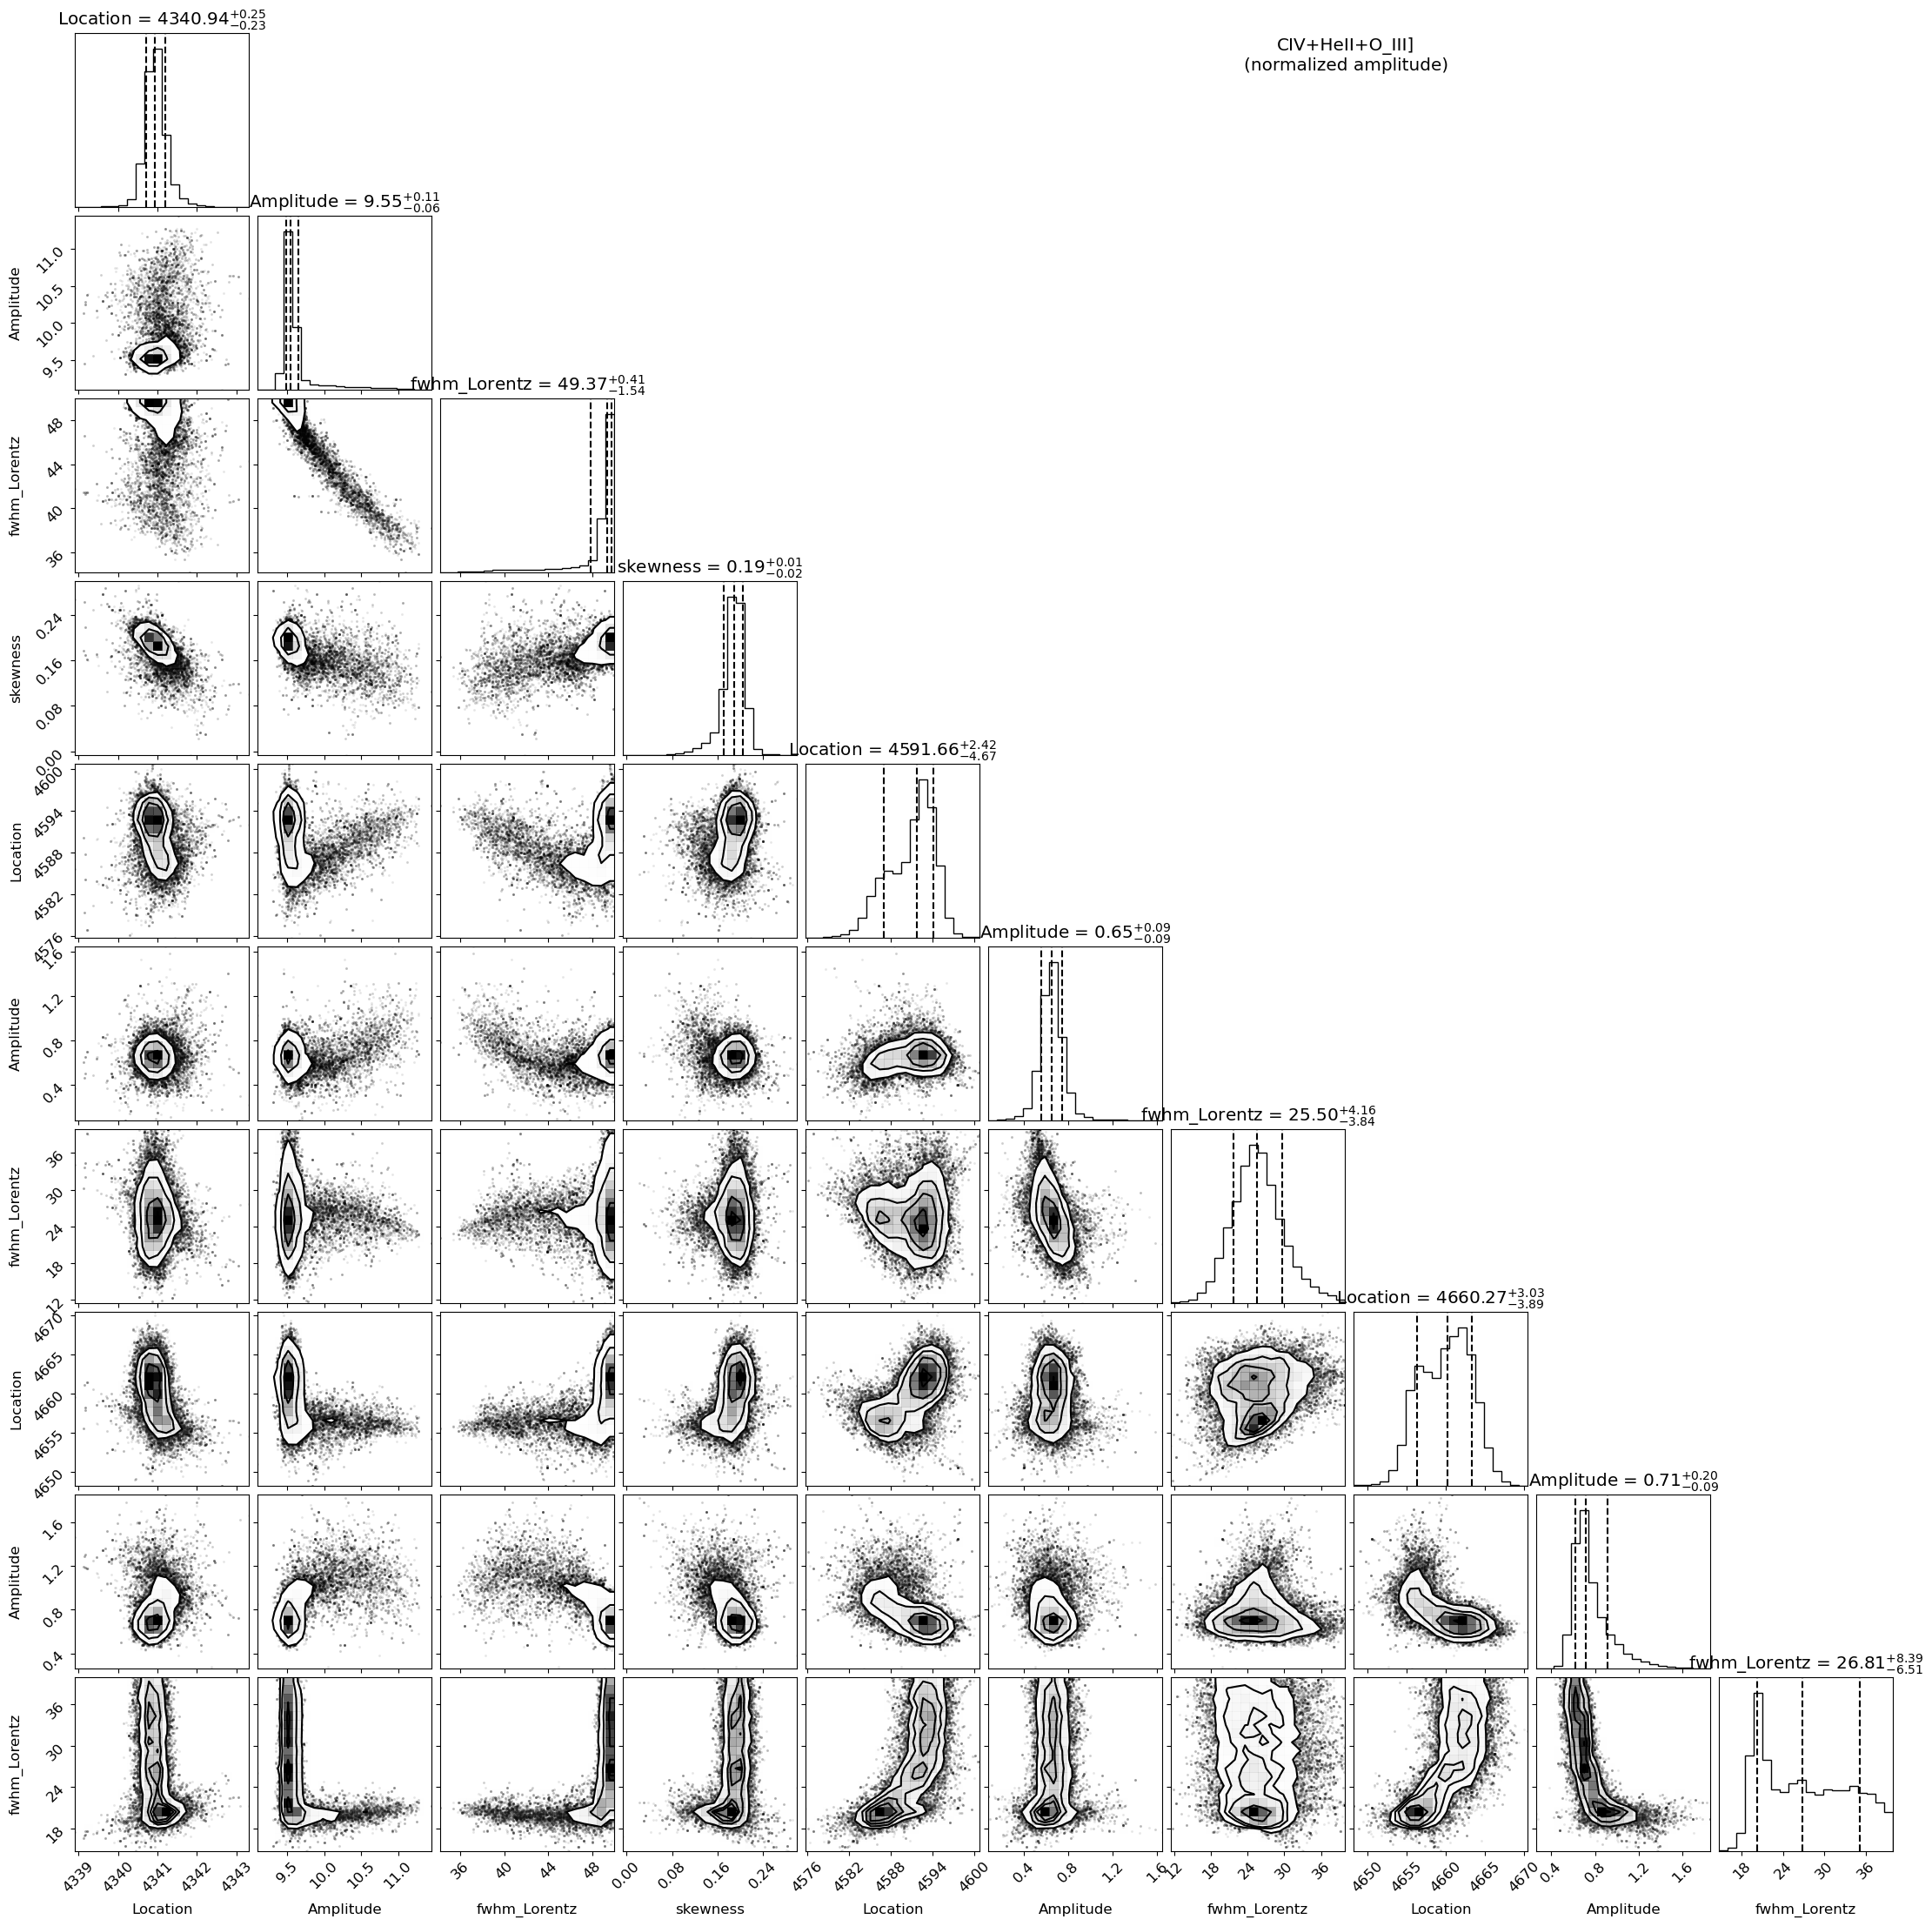

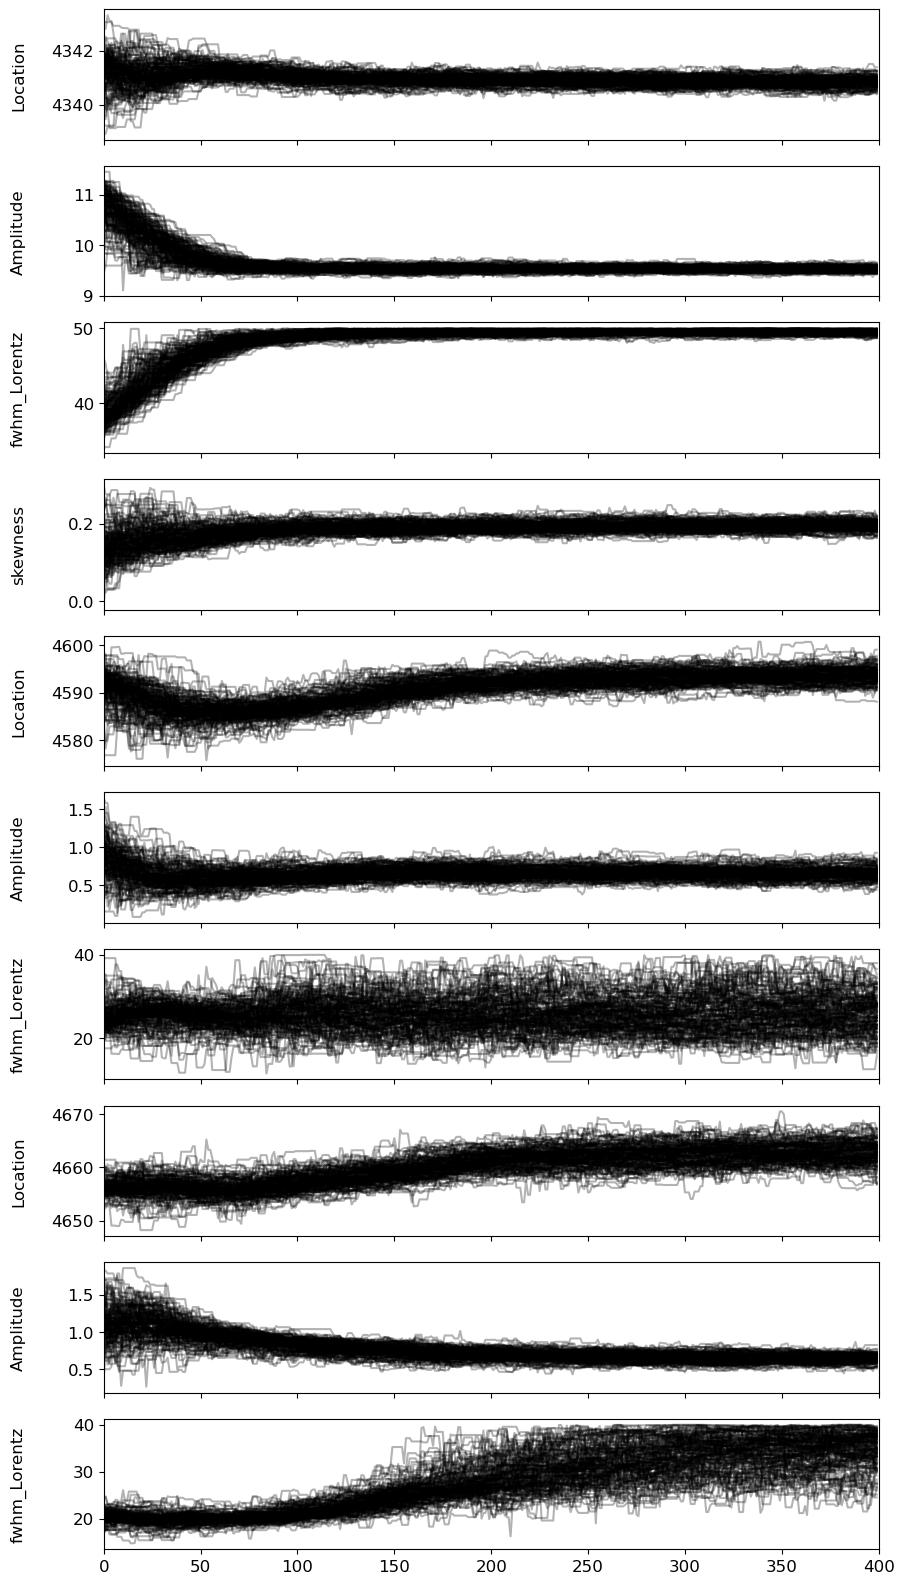

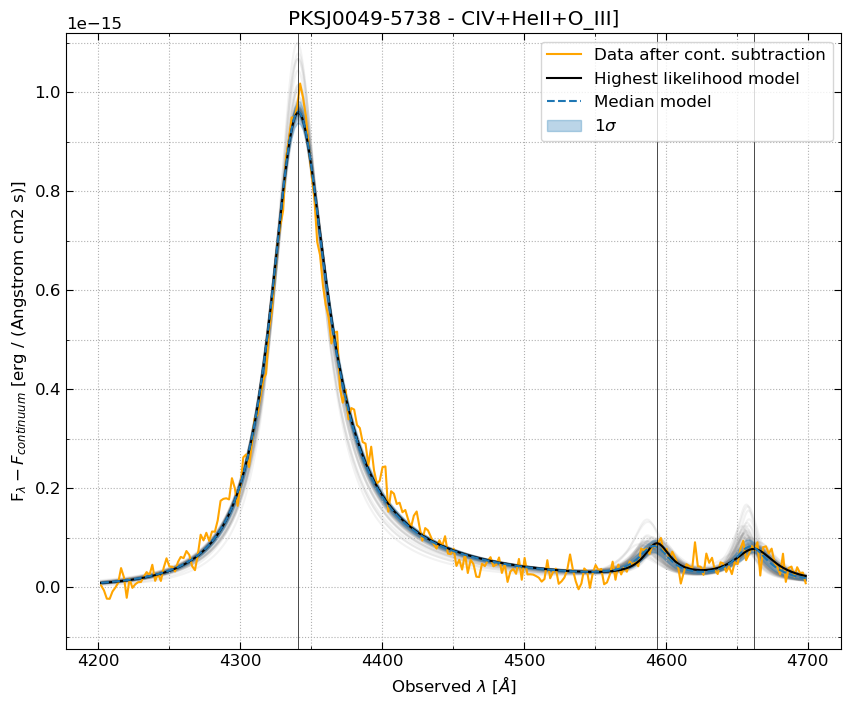

In [13]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 350, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 150, MCMC_iterations = 400, MCMC_burn_in=100, MCMC_show_progress=False, plot_spec = False, plot_MCMC = True,
                    overplot_median_model = True, save_results=True)

Excellent! The model has been successfully fitted.

### Calculating physical parameters: equivalent width, flux, velocity, and FWHM

Now, let's compute the physical parameters for these blended lines using the `line_physics()` function.

**Important note on blended lines:** when analyzing blended lines, only the values derived from the **model** are reliable. You should disregard direct measurements like `profile_equiv_width_rest_frame` discussed in the [spectral analysis](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb) tutorial, as they cannot disentangle the individual components.

> **Correcting for instrumental broadening**
> To correct the **modeled** line widths for instrumental broadening, you can manually adjust the `par_values_list`.
>
> For example, if you've estimated the instrumental broadening at the CIV line to be $FWHM_{instr} \sim 1.5$ Å:
>
> *   **For a Lorentzian profile**, subtract the instrumental width from the FWHM parameter:
>     `par_values_list[0][3] = par_values_list[0][3] - 1.5`
> *   **For a Gaussian profile**, subtract it in quadrature from the FWHM parameter:
>     `par_values_list[0][3] = $\sqrt{par\_values\_list[0][3]^2 - 1.5^2}$`

In [14]:
_, modeled_equiv_width_rest_frame, _, modeled_integrated_flux, _, modeled_rest_frame_disp_velocity, _, _, modeled_rest_frame_fhwm = analysis.line_physics(wavelengths, flux_density, continuum_baseline, par_values_list, par_values_errors_list, par_names_list, line_windows, line_std_deviation_slice, plot = False)

Let's check the results one by one (each element here contains three values: the first represents the maximum likelihood MCMC value, and the following two values represent the asymmetrical errors):

In [15]:
modeled_equiv_width_rest_frame

<Quantity [[-50.38848949,   0.3789405 ,   0.21081251],
           [ -1.40915857,   0.06629745,   0.06915125],
           [ -1.49777828,   0.06854746,   0.1323228 ]] Angstrom>

In [16]:
modeled_integrated_flux

<Quantity [[6.29221361e-14, 4.73186714e-16, 2.63229323e-16],
           [1.66139167e-15, 7.81461064e-17, 8.15114786e-17],
           [1.73727585e-15, 7.94951304e-17, 1.53474634e-16]] erg / (cm2 s)>

The modeled dispersion velocity shown below is then computed as $v = \frac{1}{2} \times c \times \frac{FWHM}{\lambda_0}$ for a Lorentzian profile, or as $v = \frac{1}{2\sqrt{2\ln 2}} \times c \times \frac{FWHM}{\lambda_0}$ for a Gaussian or Voigt profile. Here $c$ is the speed of light and $\lambda_0$ is the line peak position in wavelength. For the asymmetrical dispersion velocity we do $v = c \times \frac{\sigma_{rms}}{\lambda_0}$, where $\sigma_{rms}$ is the line dispersion computed based on the fitted model.

In [17]:
modeled_rest_frame_disp_velocity

<Quantity [[2451.53723428,   17.13053088,   17.13053088],
           [ 832.34876567,  125.46452569,  135.8880016 ],
           [ 862.40516685,  209.45356493,  269.88423173]] km / s>

In [18]:
modeled_rest_frame_fhwm

<Quantity [[17.8109133 ,  0.35973919,  0.35973919],
           [ 9.10886768,  1.37306122,  1.48710774],
           [ 9.57357104,  2.32516046,  2.99599485]] Angstrom>

### Building a synthetic spectrum

We can directly access any line model from `analysis.line_models`. For instance:

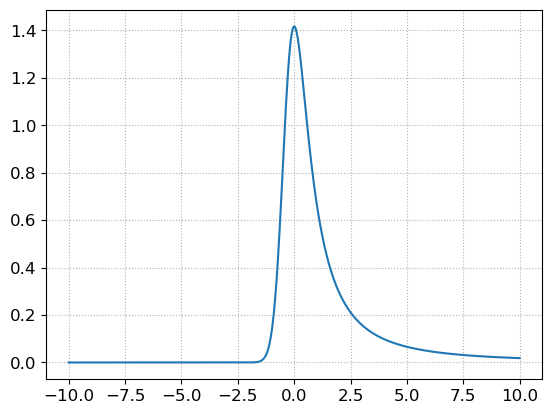

In [19]:
x = np.linspace(-10,10,1000)
theta = [0,1,2,2.3]
skewed_model = analysis.line_models.model_skewed_lorentzian(theta,x)
plt.plot(x,skewed_model)
plt.grid(ls=":")

We can also use the `wavelength` array defined at the beginning of this tutorial to build a synthetic spectrum:

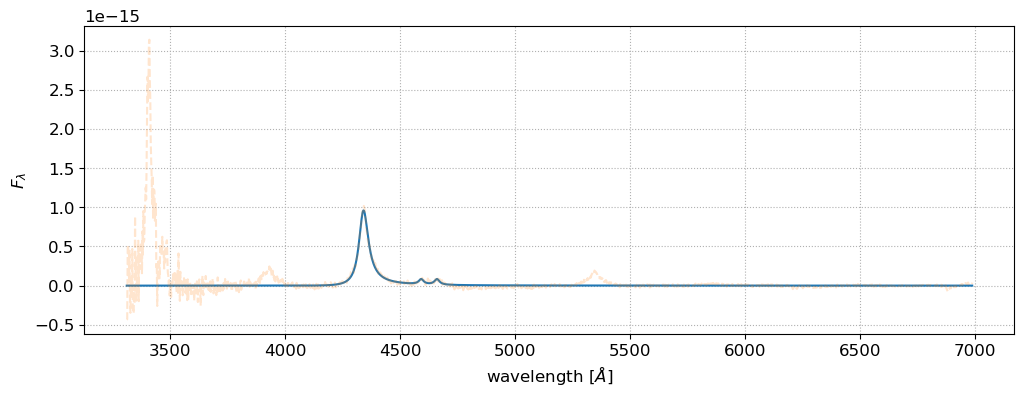

In [20]:
wavelengths_syn = wavelengths.value
theta_CIV = par_values_list[0][1:]
skewed_model_CIV = analysis.line_models.model_skewed_lorentzian(theta_CIV,wavelengths_syn)

theta_HeII = par_values_list[1][1:]
skewed_model_HeII = analysis.line_models.model_Lorentz(theta_HeII,wavelengths_syn)

theta_OIII = par_values_list[2][1:]
skewed_model_OIII = analysis.line_models.model_Lorentz(theta_OIII,wavelengths_syn)

plt.figure(figsize=(12,4))
plt.plot(wavelengths,skewed_model_CIV+skewed_model_HeII+skewed_model_OIII)
plt.plot(wavelengths,flux_density.value-continuum_baseline,ls="--",alpha=0.2)
plt.grid(ls=":")
plt.ylabel("$F_{\lambda}$")
plt.xlabel("wavelength [$\AA$]");
